In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.patches as mpatches

In [ ]:
in_afdc = pd.read_csv(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\alt_fuel_stations (Nov 14 2024).csv")
in_county = gpd.read_file(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\County_Boundaries_of_Indiana_2023.geojson")
# in_cs = gpd.read_file(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\AFDC Data\IN_charging_station_202402.shp")

# Convert latitude and longitude to a geometry column
geometry = [Point(xy) for xy in zip(in_afdc['Longitude'], in_afdc['Latitude'])]
gdf = gpd.GeoDataFrame(in_afdc, geometry=geometry)

# Define the coordinate reference system (CRS) as WGS84 (EPSG:4326)
in_cs = gdf.set_crs(epsg=4326, inplace=True)

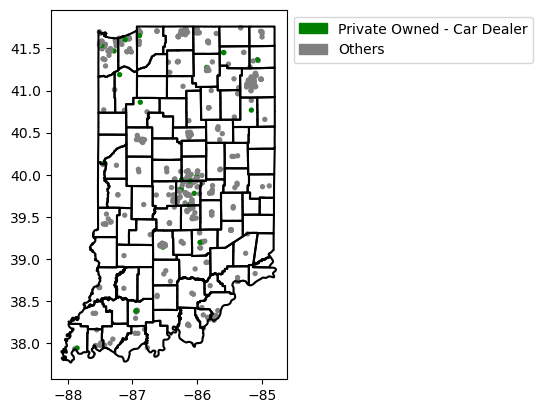

In [5]:
import matplotlib.patches as mpatches
# Create a single figure and axes
fig, ax = plt.subplots()

# Plot both datasets on the same axes
in_cs.plot(
    ax=ax, 
    color=np.where(
        (in_cs['Owner Type Code'] == 'P') & (in_cs['Facility Type'] == 'CAR_DEALER'), 'green', 'gray'
    ),
    markersize=8
)

in_county.boundary.plot(ax=ax, color = 'black')

# Create custom legend
green_patch = mpatches.Patch(color='green', label='Private Owned - Car Dealer')
red_patch = mpatches.Patch(color='gray', label='Others')
ax.legend(handles=[green_patch, red_patch], loc='upper left', bbox_to_anchor=(1, 1))

plt.savefig(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\IN_Private Car dealer vs Other.png",
                bbox_inches='tight', dpi =900)

# Show the combined plot
plt.show()

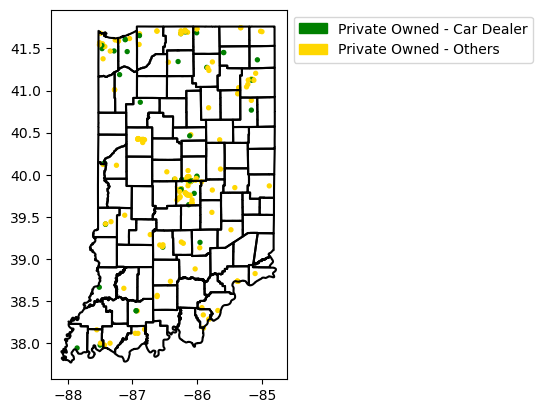

In [4]:
priv_cs = in_cs[in_cs['Owner Type Code'] == 'P']
# Create a single figure and axes
fig, ax = plt.subplots()

# Plot both datasets on the same axes
priv_cs.plot(
    ax=ax, 
    color=np.where(
        (priv_cs['Facility Type'] == 'CAR_DEALER'), 'green', 'gold'
    ),
    markersize=8
)

in_county.boundary.plot(ax=ax, color = 'black')

# Create custom legend
green_patch = mpatches.Patch(color='green', label='Private Owned - Car Dealer')
red_patch = mpatches.Patch(color='gold', label='Private Owned - Others')
ax.legend(handles=[green_patch, red_patch], loc='upper left', bbox_to_anchor=(1, 1))

plt.savefig(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\IN_Private Car Dealer vs Private Other.png",
                bbox_inches='tight', dpi =900)

# Show the combined plot
plt.show()

## Task 2: AM PM Peak

In [ ]:
import os

In [11]:
in_road = gpd.read_file(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\OSM Network File\Updated_Shapefile\indianametsr.shp")
# in_state = gpd.read_file(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\AFDC Data\Indiana_State_Boundary_2020.geojson")

In [ ]:
# Folder containing the CSV files
folder_path = r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\Google Traffic Speed\{}"
peak = ["Afternoon_Peak", "Morning_Peak"]

traffic = {p: {} for p in peak}

for p in peak:
    current_folder = folder_path.format(p)
    temp = pd.DataFrame(columns=['value', 'x', 'y', 'geometry'])
    for f in os.listdir(current_folder):
        file_path = os.path.join(current_folder, f)
        # Read the CSV
        df = pd.read_csv(file_path)
        temp = pd.concat([temp,df], axis = 0, ignore_index=True)
        print(temp.tail())
    
    gdf = gpd.GeoDataFrame(temp, geometry=gpd.points_from_xy(temp['x'], temp['y']))
    traf = gdf.set_crs(epsg=4326, inplace=True)
    traffic[p] = traf

       value          x          y geometry
115907     1 -84.959336  40.570331      NaN
115908     1 -84.959251  40.570331      NaN
115909     1 -84.958993  40.570331      NaN
115910     1 -84.958907  40.570331      NaN
115911     1 -84.959422  40.570267      NaN
       value          x          y geometry
791577     1 -85.167167  40.916644      NaN
791578     1 -85.166909  40.916644      NaN
791579     1 -85.166823  40.916644      NaN
791580     1 -85.167252  40.916580      NaN
791581     1 -85.167167  40.916580      NaN
       value          x          y geometry
975750     1 -85.905096  39.040405      NaN
975751     1 -85.905010  39.040405      NaN
975752     1 -85.904925  39.040405      NaN
975753     1 -85.904839  39.040405      NaN
975754     1 -85.904753  39.040405      NaN
        value          x          y geometry
1051019     1 -87.254646  40.476283      NaN
1051020     1 -87.254732  40.476218      NaN
1051021     1 -87.254646  40.476218      NaN
1051022     1 -87.254732  40

        value          x          y geometry
4153441     3 -85.894168  39.722130      NaN
4153442     3 -85.894425  39.722064      NaN
4153443     3 -85.894339  39.722064      NaN
4153444     3 -85.894253  39.722064      NaN
4153445     3 -85.894168  39.722064      NaN
        value          x          y geometry
4153886     3 -86.121063  38.178770      NaN
4153887     3 -86.120977  38.178770      NaN
4153888     3 -86.121149  38.178702      NaN
4153889     3 -86.121063  38.178702      NaN
4153890     3 -86.120977  38.178702      NaN
        value          x          y geometry
4501776     1 -86.516312  39.600764      NaN
4501777     1 -86.516227  39.600764      NaN
4501778     1 -86.516141  39.600764      NaN
4501779     1 -86.516055  39.600764      NaN
4501780     1 -86.515969  39.600764      NaN
        value          x          y geometry
4502207     1 -85.538644  39.794212      NaN
4502208     1 -85.538558  39.794212      NaN
4502209     1 -85.538472  39.794212      NaN
4502210   

        value          x          y geometry
9294739     1 -86.614949  38.395508      NaN
9294740     1 -86.614863  38.395508      NaN
9294741     1 -86.614692  38.395508      NaN
9294742     1 -86.614606  38.395508      NaN
9294743     1 -86.614520  38.395508      NaN
        value          x          y geometry
9295018     3 -86.792649  39.263543      NaN
9295019     3 -86.792563  39.263543      NaN
9295020     3 -86.792992  39.263476      NaN
9295021     3 -86.792906  39.263476      NaN
9295022     3 -86.792820  39.263476      NaN
        value          x          y geometry
9402324     1 -87.120692  39.605769      NaN
9402325     1 -87.120520  39.605769      NaN
9402326     1 -87.120434  39.605769      NaN
9402327     1 -87.120349  39.605769      NaN
9402328     1 -87.120263  39.605769      NaN
        value          x          y geometry
9474320     1 -86.729238  37.901996      NaN
9474321     1 -86.729410  37.901929      NaN
9474322     1 -86.729324  37.901929      NaN
9474323   

         value          x          y geometry
12438981     1 -87.268112  37.918766      NaN
12438982     1 -87.268284  37.918698      NaN
12438983     1 -87.268198  37.918698      NaN
12438984     1 -87.268112  37.918698      NaN
12438985     1 -87.268112  37.918631      NaN
         value          x          y geometry
12567742     1 -86.028438  38.418330      NaN
12567743     1 -86.028523  38.418263      NaN
12567744     1 -86.028438  38.418263      NaN
12567745     1 -86.028523  38.418196      NaN
12567746     1 -86.028438  38.418196      NaN
         value          x          y geometry
12784097     1 -85.109529  39.715073      NaN
12784098     1 -85.109443  39.715073      NaN
12784099     1 -85.109872  39.715007      NaN
12784100     1 -85.109529  39.715007      NaN
12784101     1 -85.109443  39.715007      NaN
         value          x          y geometry
12915690     1 -85.278098  40.567255      NaN
12915691     1 -85.371706  40.567190      NaN
12915692     1 -85.371620  40.5671

        value          x          y geometry
1750319     3 -87.549769  38.194936      NaN
1750320     3 -87.549683  38.194936      NaN
1750321     3 -87.549597  38.194936      NaN
1750322     3 -87.469803  38.194936      NaN
1750323     3 -87.469718  38.194936      NaN
        value          x          y geometry
1947988     1 -85.843320  40.378519      NaN
1947989     1 -85.843234  40.378519      NaN
1947990     1 -85.843063  40.378519      NaN
1947991     1 -85.842977  40.378519      NaN
1947992     1 -85.842891  40.378519      NaN
        value          x          y geometry
1948313     3 -86.920131  38.915122      NaN
1948314     3 -86.920388  38.915055      NaN
1948315     3 -86.920302  38.915055      NaN
1948316     3 -86.920216  38.915055      NaN
1948317     3 -86.920302  38.914989      NaN
        value          x          y geometry
1950713     4 -86.112370  39.926973      NaN
1950714     4 -86.112799  39.926908      NaN
1950715     4 -86.112284  39.926908      NaN
1950716   

        value          x          y geometry
5484001     1 -85.251358  41.263854      NaN
5484002     1 -85.251273  41.263854      NaN
5484003     1 -85.251187  41.263854      NaN
5484004     1 -85.251101  41.263854      NaN
5484005     1 -85.251015  41.263854      NaN
        value          x          y geometry
5508168     1 -84.987263  38.901532      NaN
5508169     1 -84.987692  38.901466      NaN
5508170     1 -84.987606  38.901466      NaN
5508171     1 -84.987349  38.901466      NaN
5508172     1 -84.987263  38.901466      NaN
        value          x          y geometry
5508517     1 -86.442834  38.507666      NaN
5508518     1 -86.442748  38.507599      NaN
5508519     1 -86.442663  38.507532      NaN
5508520     1 -86.442577  38.507465      NaN
5508521     1 -86.442577  38.507398      NaN
        value          x          y geometry
5508903     1 -86.792820  39.263808      NaN
5508904     1 -86.791791  39.263808      NaN
5508905     1 -86.813670  39.246570      NaN
5508906   

        value          x          y geometry
7341279     1 -86.028867  38.418263      NaN
7341280     1 -86.028781  38.418263      NaN
7341281     1 -86.028867  38.418196      NaN
7341282     1 -86.028781  38.418196      NaN
7341283     1 -86.028867  38.418129      NaN
        value          x          y geometry
7550118     1 -85.109529  39.715073      NaN
7550119     1 -85.109443  39.715073      NaN
7550120     1 -85.109872  39.715007      NaN
7550121     1 -85.109529  39.715007      NaN
7550122     1 -85.109443  39.715007      NaN
        value         x          y geometry
7550610     1 -85.37162  40.581793      NaN
7550611     1 -85.37162  40.581728      NaN
7550612     1 -85.37162  40.581663      NaN
7550613     1 -85.37162  40.581598      NaN
7550614     1 -85.37162  40.581533      NaN
        value          x          y geometry
7715204     1 -86.869210  40.561717      NaN
7715205     1 -86.869124  40.561717      NaN
7715206     1 -86.868952  40.561717      NaN
7715207     1 -8

In [6]:
traf_am = gpd.read_file(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\IN_Morning_Peak.geojson")

In [12]:
# Ensure both GeoDataFrames use the same CRS
traf_am = traf_am.to_crs(in_road.crs)

In [48]:
from scipy.spatial import cKDTree

# Extract coordinates from the points GeoDataFrame
points_coords = traf_am.geometry.apply(lambda geom: (geom.x, geom.y)).tolist()

# Create a KDTree for fast spatial indexing of the points
points_tree = cKDTree(points_coords)

# Function to find the closest point and get its 'value'
def get_closest_point_value(line_geom):
    # Get the centroid of the line geometry
    centroid = line_geom.centroid
    # Query the KDTree to find the index of the closest point
    _, idx = points_tree.query((centroid.x, centroid.y))
    # Return the 'value' of the closest point
    return traf_am.iloc[idx]['value']

# Apply the function to each line geometry and create a new 'value' column in lines_gdf
in_road['value'] = in_road.geometry.apply(get_closest_point_value)

In [49]:
in_road['value'] = in_road['value'].apply(pd.to_numeric)

In [ ]:
# Find the closest point for each line
closest_values = []
count = 0

for line in in_road.geometry:
    count += 1
    print(count, sep = ' ')
    # Compute distances to all points
    distances = traf_am.geometry.distance(line)
    # Find the index of the closest point
    closest_index = distances.idxmin()
    # Get the 'value' of the closest point
    closest_values.append(traf_am.loc[closest_index, 'value'])

# Add the closest 'value' to the line GeoDataFrame
in_road['closest_value'] = closest_values

In [26]:
cols = np.where((in_road['value'] == 1), 'green',
               np.where((in_road['value'] == 2),'orange', 
                        np.where((in_road['value'] == 3),'red', 'darkred'))
               )

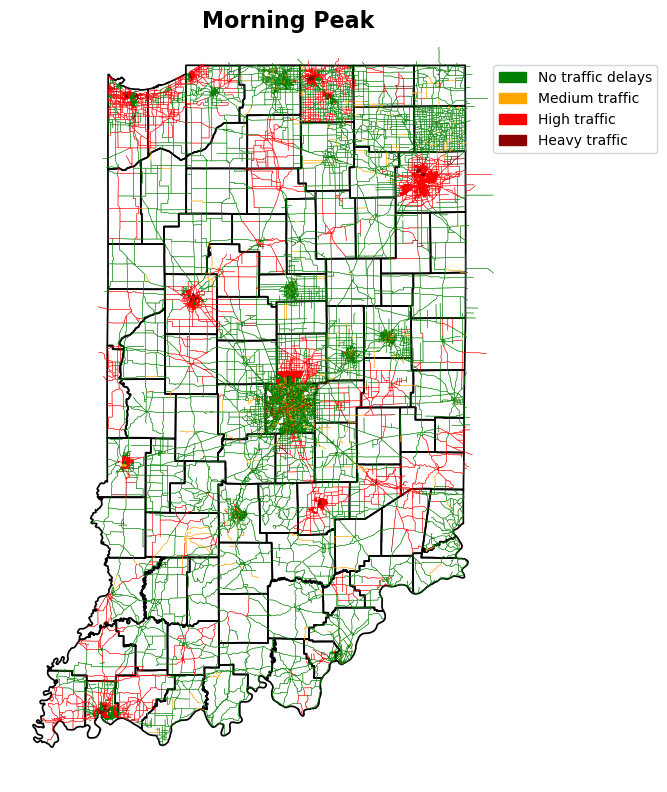

In [51]:
# Define a color map based on the 'value' column
color_map = {1: 'green', 2: 'orange', 3: 'red', 4: 'darkred'}

# Plot the lines with the specified colors
fig, ax = plt.subplots(figsize=(10, 10))
in_county = in_county.to_crs(in_road.crs)
in_county.boundary.plot(ax=ax, color='black', linewidth=1.25)
for value, color in color_map.items():
    in_road[in_road['value'] == value].plot(ax=ax, color=color, linewidth=0.3)
    
# Create custom legend
green_patch = mpatches.Patch(color='green', label='No traffic delays')
orange_patch = mpatches.Patch(color='orange', label='Medium traffic')
red_patch = mpatches.Patch(color='red', label='High traffic')
darkred_patch = mpatches.Patch(color='darkred', label='Heavy traffic')
ax.legend(handles=[green_patch, orange_patch, red_patch, darkred_patch], bbox_to_anchor = (0.94,0.94), loc='upper left')
ax.text(0.55, 0.98, "Morning Peak", transform=ax.transAxes, fontsize=16, fontweight='bold', ha='center')
ax.set_axis_off()

plt.savefig(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\IN_AMPEAK.png",
            bbox_inches='tight', dpi =900)
plt.show()

In [31]:
traf_pm = gpd.read_file(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\IN_Afternoon_Peak.geojson")

In [32]:
# Ensure both GeoDataFrames use the same CRS
traf_pm = traf_pm.to_crs(in_road.crs)

In [33]:
from scipy.spatial import cKDTree

# Extract coordinates from the points GeoDataFrame
points_coords = traf_pm.geometry.apply(lambda geom: (geom.x, geom.y)).tolist()

# Create a KDTree for fast spatial indexing of the points
points_tree = cKDTree(points_coords)

# Function to find the closest point and get its 'value'
def get_closest_point_value(line_geom):
    # Get the centroid of the line geometry
    centroid = line_geom.centroid
    # Query the KDTree to find the index of the closest point
    _, idx = points_tree.query((centroid.x, centroid.y))
    # Return the 'value' of the closest point
    return traf_pm.iloc[idx]['value']

# Apply the function to each line geometry and create a new 'value' column in lines_gdf
in_road['value'] = in_road.geometry.apply(get_closest_point_value)

In [34]:
in_road['value'] = in_road['value'].apply(pd.to_numeric)

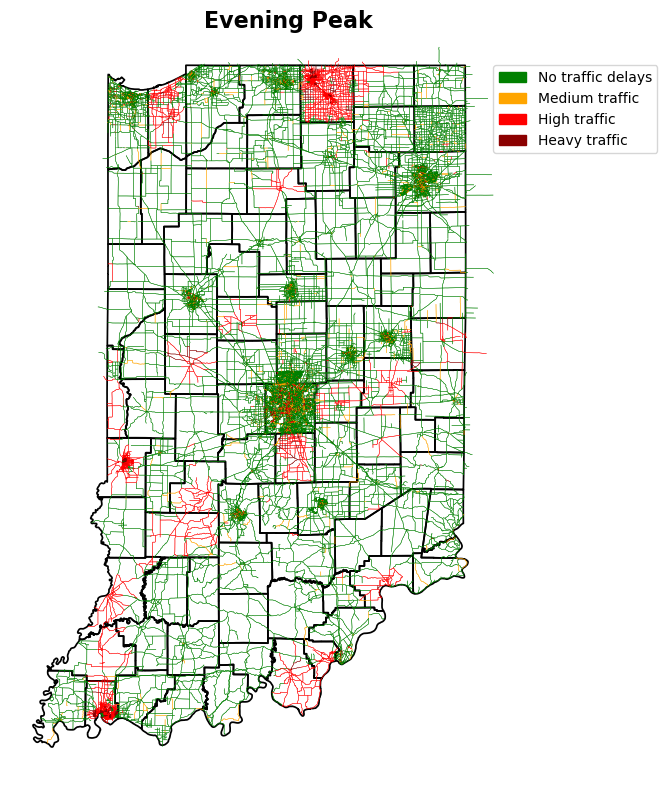

In [ ]:
# Define a color map based on the 'value' column
color_map = {1: 'green', 2: 'orange', 3: 'red', 4: 'darkred'}

# Plot the lines with the specified colors
fig, ax = plt.subplots(figsize=(10, 10))
in_county = in_county.to_crs(in_road.crs)
in_county.boundary.plot(ax=ax, color='black', linewidth=1.25)
for value, color in color_map.items():
    in_road[in_road['value'] == value].plot(ax=ax, color=color, linewidth=0.3)
    
# Create custom legend
green_patch = mpatches.Patch(color='green', label='No traffic delays')
orange_patch = mpatches.Patch(color='orange', label='Medium traffic')
red_patch = mpatches.Patch(color='red', label='High traffic')
darkred_patch = mpatches.Patch(color='darkred', label='Heavy traffic')
ax.legend(handles=[green_patch, orange_patch, red_patch, darkred_patch], bbox_to_anchor = (0.94,0.94), loc='upper left')

ax.text(0.55, 0.98, "Evening Peak", transform=ax.transAxes, fontsize=16, fontweight='bold', ha='center')
ax.set_axis_off()

plt.savefig(r"C:\Users\kenny\OneDrive - purdue.edu\Documents\Kenny's File\Transportation Literature\Fall 2023\SPR 4811 - Simulating Current and Future EV Growth in Indiana\IN_PMPEAK.png",
            bbox_inches='tight', dpi =900)

plt.show()